Original Exercise Dataset:
   Unnamed: 0  id     diet  pulse    time  kind
0           0   1  low fat     85   1 min  rest
1           1   1  low fat     85  15 min  rest
2           2   1  low fat     88  30 min  rest
3           3   2  low fat     90   1 min  rest
4           4   2  low fat     92  15 min  rest

Merged Fitness Data:
   id  pulse_1_minute  pulse_30_minutes
0  21              93               110
1  22              98               112
2  23              98                99
3  24              87               120
4  25              94               116
5  26              95               143
6  27             100               140
7  28             103               140
8  29              94               130
9  30              99               150

Sorted Fitness Progress:
   id  pulse_1_minute  pulse_30_minutes  pulse_progress
9  30              99               150              51
5  26              95               143              48
6  27             100        

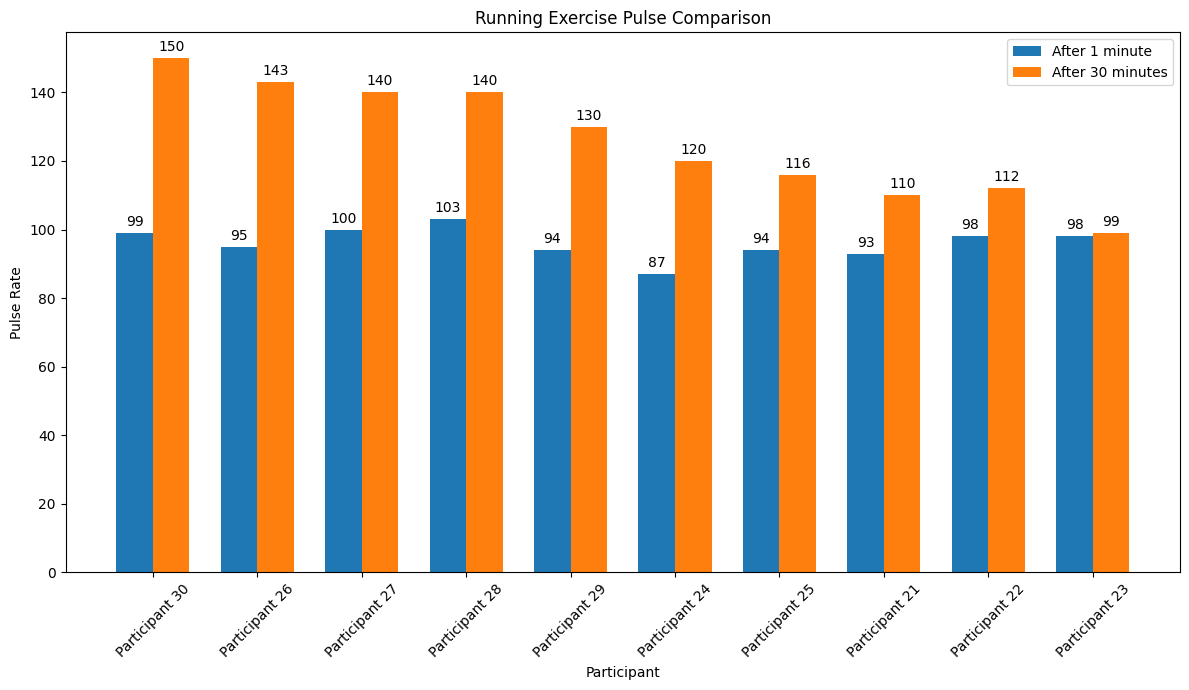

In [1]:
# Fitness Progress Comparison Chart
 
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
 
# Load Seaborn's exercise example dataset
exercise_df = sns.load_dataset("exercise")
 
print("Original Exercise Dataset:")
print(exercise_df.head())
 
 
# ---------------------------------
# PART 1: Filter the Data
# ---------------------------------
 
# Select only the running exercise records
running_data = exercise_df.loc[
    exercise_df["kind"] == "running"
]
 
# Extract pulse readings recorded after 1 minute
one_minute_data = running_data.loc[
    running_data["time"] == "1 min",
    ["id", "pulse"]
]
 
# Extract pulse readings recorded after 30 minutes
thirty_minute_data = running_data.loc[
    running_data["time"] == "30 min",
    ["id", "pulse"]
]
 
 
# ---------------------------------
# PART 2: Merge Both DataFrames
# ---------------------------------
 
# Merge the 1-minute and 30-minute records
fitness_merge = one_minute_data.merge(
    thirty_minute_data,
    on="id",
    suffixes=("_1_minute", "_30_minutes")
)
 
print("\nMerged Fitness Data:")
print(fitness_merge)
 
 
# ---------------------------------
# PART 3: Create and Sort a New Column
# ---------------------------------
 
# Calculate the increase in pulse rate
fitness_merge["pulse_progress"] = (
    fitness_merge["pulse_30_minutes"]
    - fitness_merge["pulse_1_minute"]
)
 
# Sort participants by pulse progress
fitness_merge = fitness_merge.sort_values(
    "pulse_progress",
    ascending=False
)
 
print("\nSorted Fitness Progress:")
print(fitness_merge)
 
 
# ---------------------------------
# PART 4: Create a Dictionary
# ---------------------------------
 
# Create participant labels
participant_names = [
    "Participant " + str(participant_id)
    for participant_id in fitness_merge["id"]
]
 
# Store the chart information in a dictionary
fitness_data = {
    "participant": participant_names,
    "pulse_1_minute": fitness_merge[
        "pulse_1_minute"
    ].tolist(),
    "pulse_30_minutes": fitness_merge[
        "pulse_30_minutes"
    ].tolist()
}
 
# Convert the dictionary into a DataFrame
chart_df = pd.DataFrame(fitness_data)
 
print("\nChart Data:")
print(chart_df)
 
 
# ---------------------------------
# PART 5: Create a Grouped Bar Plot
# ---------------------------------
 
positions = np.arange(
    len(chart_df["participant"])
)
 
bar_width = 0.35
 
plt.figure(figsize=(12, 7))
 
# Plot the 1-minute pulse readings
one_minute_bars = plt.bar(
    positions - bar_width / 2,
    chart_df["pulse_1_minute"],
    width=bar_width,
    label="After 1 minute"
)
 
# Plot the 30-minute pulse readings
thirty_minute_bars = plt.bar(
    positions + bar_width / 2,
    chart_df["pulse_30_minutes"],
    width=bar_width,
    label="After 30 minutes"
)
 
# Add chart details
plt.title("Running Exercise Pulse Comparison")
plt.xlabel("Participant")
plt.ylabel("Pulse Rate")
 
# Display participant labels and rotate them
plt.xticks(
    positions,
    chart_df["participant"],
    rotation=45
)
 
plt.legend()
 
 
# ---------------------------------
# PART 6: Label the Bars
# ---------------------------------
 
# Add values above the 1-minute bars
for bar in one_minute_bars:
    value = bar.get_height()
 
    plt.annotate(
        str(value),
        (
            bar.get_x() + bar.get_width() / 2,
            value
        ),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center"
    )
 
# Add values above the 30-minute bars
for bar in thirty_minute_bars:
    value = bar.get_height()
 
    plt.annotate(
        str(value),
        (
            bar.get_x() + bar.get_width() / 2,
            value
        ),
        textcoords="offset points",
        xytext=(0, 5),
        ha="center"
    )
 
# Adjust spacing and display the chart
plt.tight_layout()
plt.show()
